# Experiment of Algorithm Selection Varying Action Num

In this notebook, we compare the selection accuracy of AVG and MID using A/B testing data (and IPS using offline data) varying action num.

In [1]:
import os
import contextlib
import warnings

import numpy as np
import pandas as pd
from tqdm import tqdm
import joblib
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from scipy import stats

from dataset import KuaiRecDataset
from estimation import run_experiment
from utils import evaluate_performance

warnings.filterwarnings('ignore')

## Experiment

In [2]:
# experiment configuration
n_sims = 10000 # number of simulation runs
n0_data = 500 # sample size logged from policy 0 (algorithm A)
n1_data = 500 # sample size logged from policy 1 (algorithm B)
n_actions_list = list(range(20, 40+1)) # number of actions to vary
reward_std = 5.0 # level of noise on the reward
reward_type = "continuous" # binary or continuous

# policy params
# - policy_kind: the kind of conditioned action distribution
# - mu_rate: the peak position rate of the action distribution
# - sigma: the length of tail
policy_0_params = {"policy_kind": "sorted_normal", "mu_rate": 0.25, "sigma": 8.0}
policy_1_params = {"policy_kind": "sorted_normal", "mu_rate": 0.75, "sigma": 8.0}

In [3]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [ ]:
def estimate(n_actions):
    dataset = KuaiRecDataset(
        n_actions=n_actions,
        reward_std=reward_std,
        random_state=os.getpid()
    )

    true_value_of_0_policy = dataset.calc_policy_value(policy_params=policy_0_params)
    true_value_of_1_policy = dataset.calc_policy_value(policy_params=policy_1_params)
    true_value_of_mid_policy = dataset.calc_mid_policy_value(
        policy_0_params=policy_0_params, policy_1_params=policy_1_params
    )
    is_1_policy_better = np.int32(true_value_of_0_policy < true_value_of_1_policy)
    is_1_policy_better = is_1_policy_better - (1 - is_1_policy_better)

    estimated_pi_0_value_list = []
    estimated_pi_1_value_list = []
    estimated_pi_m_D_1_value_list = []
    estimated_pi_m_D_0_value_list = []
    estimated_comparison_list = []
    estimated_p_value_list = []

    for _ in range(n_sims):
        D_E_0 = dataset.generate_dataset(
            n_data=n0_data,
            logging_policy_params=policy_0_params,
            evaluation_policy_params=policy_1_params
        )
        D_E_1 = dataset.generate_dataset(
            n_data=n1_data,
            logging_policy_params=policy_1_params,
            evaluation_policy_params=policy_0_params
        )

        values_of_pi_1, values_of_pi_m_D_1, values_of_pi_m_D_0, values_of_pi_0, comparison, p_value = run_experiment([D_E_0, D_E_1])
        estimated_pi_1_value_list.append(values_of_pi_1)
        estimated_pi_m_D_1_value_list.append(values_of_pi_m_D_1)
        estimated_pi_m_D_0_value_list.append(values_of_pi_m_D_0)
        estimated_pi_0_value_list.append(values_of_pi_0)
        estimated_comparison_list.append(comparison)
        estimated_p_value_list.append(p_value)

    result_df = (
        pd.concat([
            pd.DataFrame(estimated_pi_1_value_list).stack(),
            pd.DataFrame(estimated_pi_m_D_1_value_list).stack(),
            pd.DataFrame(estimated_pi_m_D_0_value_list).stack(),
            pd.DataFrame(estimated_pi_0_value_list).stack(),
            pd.DataFrame(estimated_comparison_list).stack(),
            pd.DataFrame(estimated_p_value_list).stack(),
        ], axis=1)
        .reset_index(1)
        .rename(columns={
            "level_1": "est",
            0: "pi_1_value", 1: "pi_m_D_1_value", 2: "pi_m_D_0_value",
            3: "pi_0_value", 4: "selection", 5: "p_value"
        })
    )
    result_df["n_actions"] = n_actions
    result_df["true_pi_1_value"] = true_value_of_1_policy
    result_df["true_pi_0_value"] = true_value_of_0_policy
    result_df["true_pi_m_value"] = true_value_of_mid_policy
    result_df["selection"] *= is_1_policy_better
    result_df["selection"] = result_df["selection"] == 1

    return result_df

In [5]:
with tqdm_joblib(tqdm(total=len(n_actions_list))):
    result_df_list = Parallel(n_jobs=-1, verbose=0)(
        [delayed(estimate)(n_actions) for n_actions in n_actions_list]
    )

result_df = pd.concat(result_df_list).reset_index(level=0)
result_df

100%|██████████| 21/21 [02:56<00:00,  8.40s/it]


,index,est,pi_1_value,pi_m_D_1_value,pi_m_D_0_value,pi_0_value,selection,p_value,n_actions,true_pi_1_value,true_pi_0_value,true_pi_m_value
0,0,AVG,1.336996,0.000000,0.000000,0.668965,True,0.032999,20,1.133121,0.773320,0.801097
1,0,IPS,0.880508,0.000000,0.000000,0.668965,True,0.554117,20,1.133121,0.773320,0.801097
2,0,AVG_IPS,1.336996,1.088805,0.774737,0.668965,True,0.017817,20,1.133121,0.773320,0.801097
3,0,MIN,1.336996,0.757105,0.431242,0.668965,True,0.016188,20,1.133121,0.773320,0.801097
4,0,MID,1.336996,0.960697,0.614554,0.668965,True,0.009685,20,1.133121,0.773320,0.801097
...,...,...,...,...,...,...,...,...,...,...,...,...
1049995,9999,AVG,1.016670,0.000000,0.000000,0.742371,True,0.377601,40,1.320806,0.629196,0.308372
1049996,9999,IPS,-1.194967,0.000000,0.000000,0.742371,False,0.057675,40,1.320806,0.629196,0.308372
1049997,9999,AVG_IPS,1.016670,0.538122,-0.226298,0.742371,False,0.425225,40,1.320806,0.629196,0.308372
1049998,9999,MIN,1.016670,0.243289,0.193796,0.742371,True,0.386566,40,1.320806,0.629196,0.308372


## Analyze

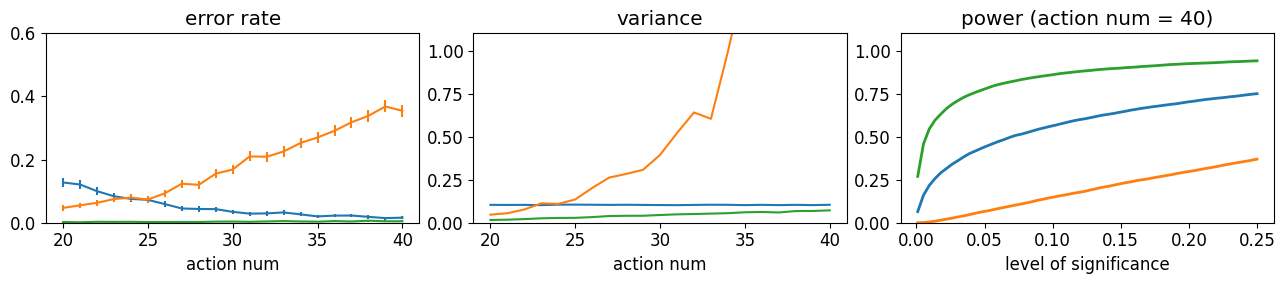

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
plt.rcParams["font.size"] = 12
for est_name in ["AVG", "IPS", "MID"]:
    mask_est = result_df["est"] == est_name
    result_dict = {
        "error rate": [],
        "error rate upper": [],
        "error rate lower": [],
        "error rate interval": [],
        "squared_bias": [],
        "variance": [],
        "MSE": [],
    }
    
    for n_actions in n_actions_list:
        mask_n_actions = result_df["n_actions"] == n_actions
        mask = mask_est & mask_n_actions
        result = result_df[mask].copy()
        performance = evaluate_performance(result)
        
        result["delta_value"] = result["pi_1_value"] - result["pi_m_D_1_value"] + result["pi_m_D_0_value"] - result["pi_0_value"]
        est_selection = result["delta_value"] > 0
        m, e, d = np.mean(est_selection), stats.sem(est_selection), len(est_selection) - 1
        interval = stats.t.interval(0.95, d, loc=m, scale=e)
        
        result_dict["error rate"].append(1.0-performance["accuracy"])
        result_dict["error rate lower"].append(1.0-interval[0])
        result_dict["error rate upper"].append(1.0-interval[1])
        result_dict["error rate interval"].append(interval[1]-interval[0])
        result_dict["squared_bias"].append(performance["squared_bias"])
        result_dict["variance"].append(performance["variance"])
        result_dict["MSE"].append(performance["MSE"])
    
    axes[0].errorbar(n_actions_list, result_dict["error rate"], yerr=result_dict["error rate interval"], label=f"{est_name}")
    axes[0].set_ylim(0.0, 0.60)
    axes[0].set_xlabel("action num")
    axes[0].set_title("error rate")
    
    axes[1].plot(n_actions_list, result_dict["variance"], label=f"{est_name}")
    axes[1].set_xlabel("action num")
    axes[1].set_title("variance")
    axes[1].set_ylim(0, 1.1)
    
    mask_n_actions = result_df["n_actions"] == 30
    mask = mask_est & mask_n_actions
    result = result_df[mask].copy()
    
    alpha_grid = np.linspace(0.001, 0.25, 60)
    power = np.array([(result["p_value"] < alpha).mean() for alpha in alpha_grid])
    axes[2].plot(alpha_grid, power, label=f'{est_name}', lw=2)
    axes[2].set_title(f"power (action num = {n_actions})")
    axes[2].set_xlabel("level of significance")
    axes[2].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()